# Search for optimal partition with minimal description length based on Map equation
The original paper proposes a greedy search followed by simulated annealing, but we're implementing the fast stochastic and recursive search algorithm that was introduced in the 2009 publication "The map equation" by M. Rosvall, D. Axelsson, and C.T. Bergstrom. It's described as follows:

## Stochastic and recursive search algorithm

Core algorithm:
- Start from each node assigned to its own module
- Node movements: in random sequential order move each node to the neighboring module that results in the largest decrease of the map equation. If no improving move can be made, the node remains in its original community
- Repeat with new random sequential order until no move generates a decrease
- Network compression: rebuild the network with the modules of the last level forming the nodes of this new compressed graph, and the edges between/within communities being aggregated
- again, perform node movement optimization tand compress the network based on the resulting community assignments. Repeat until the description length cannot be decreased further

The results of the core algorithm are then improved with the following refinement strategies:
*Submodule movements*:
- Each module is treated as a network on its own, and the main algorithm is reapplied.
- Resulting submodules are moved back to their respective modules
- Main algorithm is repeated, starting from the previous module assignments but with the submodules being freely moveable.

*Single-node movements*:
- Re-assign each node to be freely movable on its own. 
- Start from the same module partition as before, and reapply the main algorithm with each node being freely movable.

Both refinements are repeated in sequence, as long as improvements can be made. The submodule movements are applied recursively, such that the algorithm splits the modules into submodules, those into subsubmodules etc until no further splits are possible. 

This main algorithm composed of core algorithm and refinements is restarted from scratch multiple times.

### Core algorithm
The core algorithm consists of 2 phases.

Phase 1:
- initially assign each node to a different communitiy ($N$ nodes -> $N$ communities)
- for each node i, consider neighbours j, check if/how much removing i from its community and putting it into j's community improves (decreases) description length
- choose neighbour merge with best improvement. If no improvement possible, i stays in its community.
- repeat sequentially for all nodes until no further improvement can be made -> Phase 1 done!

Phase 2:
- build a new network whose nodes are the communities found in phase 1
- weights of links between new nodes correspond to sum of weight of links between old nodes in the corresponding 2 communities; links between nodes of the same community lead to self-loops for this community in the new network -> Phase 2 done! Can reapply Phase 1 to new network.

Iterate Phase 1 + Phase 2 until no further improvements are obtained.
Refinement possible with submodule/single-module movements -> can be performed in sequence until no more improvements.

We implement the following functions to tackle this:
- `update_node_move_description_length()`: Computes the change in description length for a given community partition in the event that a single node is moved from its community to another community. (for phase 1) -> Tested in `Test_infomap.ipynb`.
- `node_movement_optimization()`: Basically runs the Phase 1. Sequentially goes through nodes in random order, finds the optimal move using `update_node_move_description_length()`, and repeats until no improving moves can be made. 
- `compress_network()`: Implements Phase 2. Takes the community assignment and transforms it into a new network with nodes corresponding to the communities, and aggregates the weights of the within- and between-community links into self-loops and links between nodes on the new network. -> DONE

In [1]:
# library imports
import igraph as ig
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import timeit
import warnings
import random
import sys
sys.path.append("..") # go to parent folder
import src.infomap_funcs as inf # import infomap_funcs from src folder

### Node movement opimization (Phase 1)
Let's try to do the node movement optimization:
(Some mild confusion: One of the references makes it sound as though we keep sequentially going through all nodes again until no more improvements are possible, the other one suggests that we keep track of candidate nodes and, if at any point, a node has no further moves for improvement it is removed from the candidate pool, which unlike the first option sounds like it may neglect combinations where after a change in constellation a node that previously didn't have an improving move might now have one with the new, changed modules. We'll see? I'll start implementing option one, and then we can see if the candidate pool makes sense or not.)

Test on undirected network:

In [2]:
g_test = inf.generate_sbm(n=100, c=4, p_in=0.25, p_out=0.01, directed=False, weighted=True)
communities, L, p_mod, exit_data = inf.node_movement_optimization(g_test, returnTerms=True, verbose=True)

Initialising node movement optimization with each node in its own community.
Starting from description length: 8.507872872982649
Current best description length: 6.400893114478231
Number of nodes moved this iteration: 65
Continuing optimization.
Current best description length: 5.998352553472051
Number of nodes moved this iteration: 25
Continuing optimization.
Current best description length: 5.900103351734935
Number of nodes moved this iteration: 7
Continuing optimization.
Current best description length: 5.883789827595299
Number of nodes moved this iteration: 1
Continuing optimization.
Current best description length: 5.883789827595299
Number of nodes moved this iteration: 0
Optimization finished!
Final number of communities: 29
Final description length: 5.883789827595299


In [3]:
# check the new description length, should be same as before:
print("optimization function output L: ", L)
print("recomputed description length: ", inf.compute_description_length(g_test, communities))

optimization function output L:  5.883789827595299
recomputed description length:  5.883789827595299


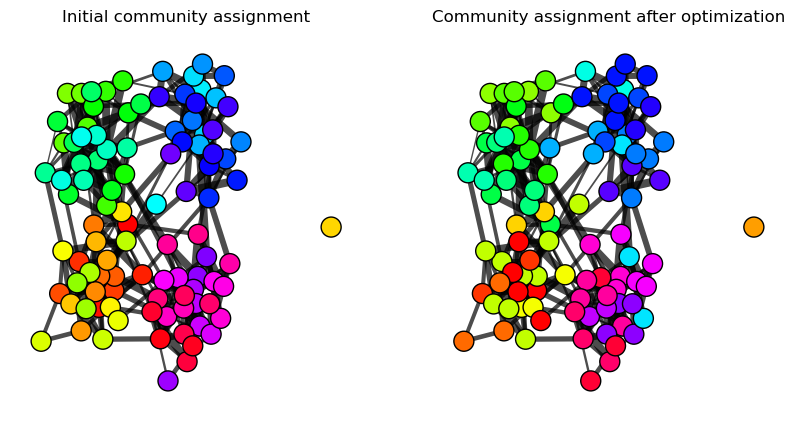

In [4]:
layout = g_test.layout('fr')
fig, ax = plt.subplots(ncols=2, figsize = (10, 5))
ig.plot(g_test, layout=layout, **inf.visual_community_colors(g_test, communities=np.arange(g_test.vcount()), skipLayout=True), target=ax[0])
ig.plot(g_test, layout=layout, **inf.visual_community_colors(g_test, communities=communities, skipLayout=True), target=ax[1])
ax[0].set_title("Initial community assignment")
ax[1].set_title("Community assignment after optimization")
plt.show()

Test on directed network:

In [5]:
g_test_directed = inf.generate_sbm(n=100, c=4, p_in=0.25, p_out=0.01, directed=True, weighted=True)
communities_directed, L, p_mod, exit_data = inf.node_movement_optimization(g_test_directed, returnTerms=True, verbose=True)

Initialising node movement optimization with each node in its own community.
Starting from description length: 8.421062110291702
Current best description length: 6.778590764090593
Number of nodes moved this iteration: 79
Continuing optimization.
Current best description length: 6.48157978904666
Number of nodes moved this iteration: 25
Continuing optimization.
Current best description length: 6.291248620298644
Number of nodes moved this iteration: 12
Continuing optimization.
Current best description length: 6.165881118812914
Number of nodes moved this iteration: 6
Continuing optimization.
Current best description length: 6.1519123112926035
Number of nodes moved this iteration: 3
Continuing optimization.
Current best description length: 6.151742957607343
Number of nodes moved this iteration: 1
Continuing optimization.
Current best description length: 6.151742957607343
Number of nodes moved this iteration: 0
Optimization finished!
Final number of communities: 11
Final description length: 

In [6]:
# check the new description length, should be same as before:
print("optimization function output L: ", L)
print("recomputed description length: ", inf.compute_description_length(g_test_directed, communities_directed))

optimization function output L:  6.151742957607343
recomputed description length:  6.151742957607343


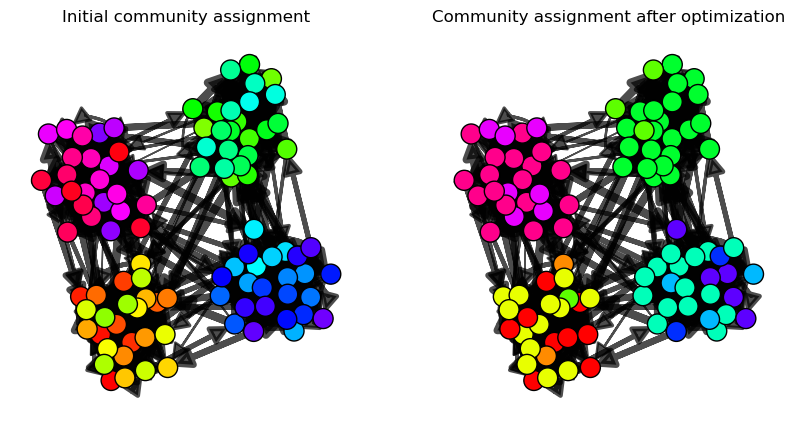

In [7]:
layout_directed = g_test_directed.layout('fr')
fig, ax = plt.subplots(ncols=2, figsize = (10, 5))
ig.plot(g_test_directed, layout=layout_directed, **inf.visual_community_colors(g_test_directed, communities=np.arange(g_test_directed.vcount()), skipLayout=True), target=ax[0])
ig.plot(g_test_directed, layout=layout_directed, **inf.visual_community_colors(g_test_directed, communities=communities_directed, skipLayout=True), target=ax[1])
ax[0].set_title("Initial community assignment")
ax[1].set_title("Community assignment after optimization")
plt.show()

### Network compression (Phase 2)
Let's test the network compression function!

Testing with undirected test network from above:

In [8]:
g_test_compressed, unique_communities = inf.compress_network(g_test, communities, verbose=True)

Input graph has 29 unique communities, 100 nodes and 309 edges.
Creating compressed graph with 29 nodes, 159 aggregated edges.


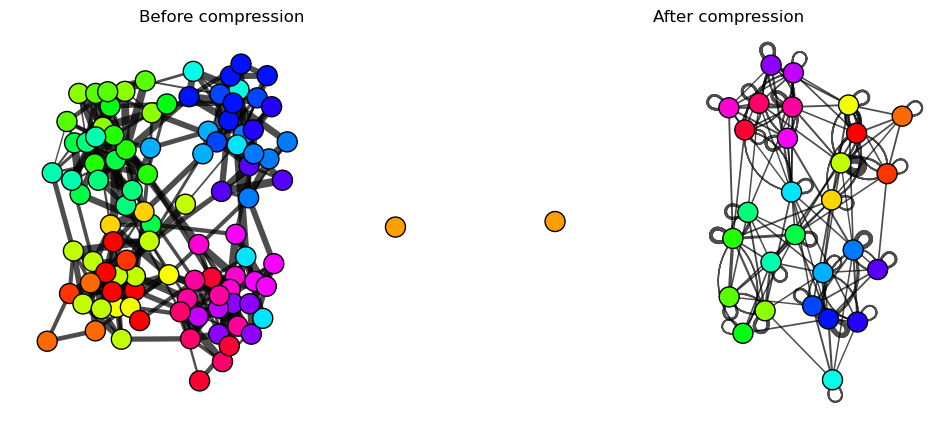

In [9]:
fig, ax = plt.subplots(ncols=2, figsize = (12, 5))
ig.plot(g_test, layout=layout, **inf.visual_community_colors(g_test, communities=communities, skipLayout=True), target=ax[0])
ig.plot(g_test_compressed, **inf.visual_community_colors(g_test_compressed, communities=range(g_test_compressed.vcount())), target=ax[1])
ax[0].set_title("Before compression")
ax[1].set_title("After compression")
plt.show()

In [10]:
# check the new description length:
print("Codelength before compression: ", inf.compute_description_length(g_test, communities))
print("Codelength after compression: ", inf.compute_description_length(g_test_compressed, range(g_test_compressed.vcount())))

Codelength before compression:  5.883789827595299
Codelength after compression:  3.9733786038429626


In [11]:
# let's check if the difference is as expected:
L,  p, p_mod, exits = inf.compute_description_length(g_test, communities, returnTerms=True)
L_comp,  p_c, p_mod_c, exits_c = inf.compute_description_length(g_test_compressed, range(g_test_compressed.vcount()), returnTerms=True)
print(f"Before compression:\nL = {L} \nH(p) = {np.sum(inf.safe_xlogx(p))} \nH(p_mod) = {np.sum(inf.safe_xlogx(p_mod))}\n")
print(f"After compression:\nL = {L_comp} \nH(p) = {np.sum(inf.safe_xlogx(p_c))} \nH(p_mod) = {np.sum(inf.safe_xlogx(p_mod_c))}")

print("Codelength difference in theory: ", np.sum(inf.safe_xlogx(p_mod)) - np.sum(inf.safe_xlogx(p)))
print("Actual codelength difference: ", L - L_comp)

Before compression:
L = 5.883789827595299 
H(p) = -6.507872872982649 
H(p_mod) = -4.59746164923031

After compression:
L = 3.9733786038429626 
H(p) = -4.597461649230311 
H(p_mod) = -4.597461649230311
Codelength difference in theory:  1.9104112237523383
Actual codelength difference:  1.9104112237523365


Testing with the directed test network from above:

In [12]:
g_test_directed_compressed, unique_communities_directed = inf.compress_network(g_test_directed, communities_directed, verbose=True)

Input graph has 11 unique communities, 100 nodes and 702 edges.
Creating compressed graph with 11 nodes, 70 aggregated edges.


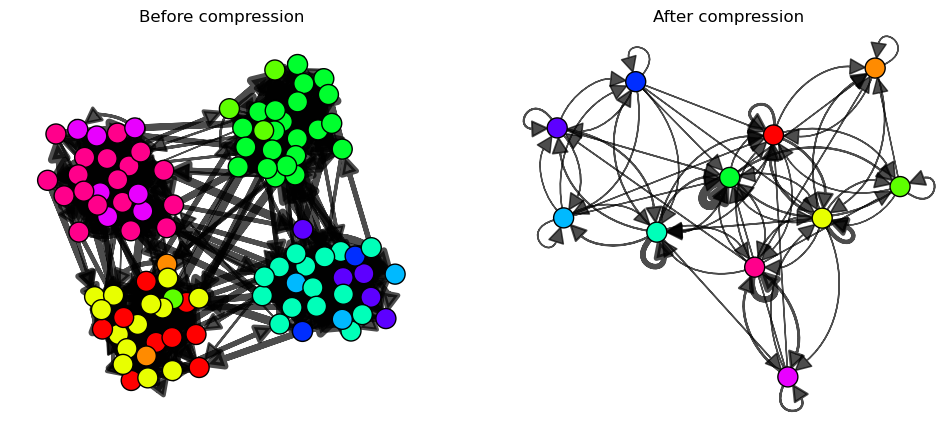

In [13]:
fig, ax = plt.subplots(ncols=2, figsize = (12, 5))
ig.plot(g_test_directed, layout=layout_directed, **inf.visual_community_colors(g_test_directed, communities=communities_directed, skipLayout=True), target=ax[0])
ig.plot(g_test_directed_compressed, **inf.visual_community_colors(g_test_directed_compressed, communities=range(g_test_directed_compressed.vcount())), target=ax[1])
ax[0].set_title("Before compression")
ax[1].set_title("After compression")
plt.show()

In [14]:
# check the new description length:
# we can't evaluate the difference as neatly as in the undirected case 
# bc with directed networks the changes are a lot more complex
print("Codelength before compression: ", inf.compute_description_length(g_test_directed, communities_directed))
print("Codelength after compression: ", inf.compute_description_length(g_test_directed_compressed, range(g_test_directed_compressed.vcount())))

Codelength before compression:  6.151742957607343
Codelength after compression:  2.9987222768668413


### Core search algorithm
Let's put everything together to implement the core search algorithm:

In [15]:
def core_search_algorithm(g:ig.Graph, teleportation="uniform", verbose=False):
    """Runs core algorithm of the infomap community partition search algorithm, without any
    refinement steps. Follows the description in "The map equation" (M. Rosvall, D. Axelsson, and C.T. Bergstrom, 2009).
    Alternates between node-movement optimization and network compression until no further improvements can be made.

    Args:
        g (ig.Graph): Input graph. Supports directed/undirected and weighted/unweighted.
        verbose (bool, optional): Whether to print verbose output for debugging. Defaults to False.

    Returns:
        list[int]: A list of integercommunity labels for each node in the input graph.
    """                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    
    N = g.vcount() # number of nodes in graph
    flat_comms = np.arange(N, dtype=int) # we'll use this to track how each node in the og graph
    # maps to the supernodes of the current compressed graph

    g_current = g 
    level = 0 # tracking the compression depth

    # start with a loop that repeats as long as we still have improvements:
    while True:
        n_current = g_current.vcount()
        if verbose:
            print(f"\n--- Level {level} ------------------------------")
            print(f"    Current Graph: {n_current} nodes, {g_current.ecount()} edges")

        L_before = inf.compute_description_length(g_current, np.arange(n_current), teleportation=teleportation)
    
        # --- Phase 1: optimization via single-node moves ---
        comms_level, L_after, _, _ = inf.node_movement_optimization(g_current, teleportation=teleportation, returnTerms=True, verbose=verbose)
        n_communities = int(np.max(comms_level)) + 1 # works bc labels should be 0 indexed & contiguous

        if verbose:
            print(f"    Phase 1 found {n_communities} communities")

        # if no improvement has been made in node movement optimization, exit loop
        if L_after >= L_before:
            if verbose:
                print("    Node movement did not improve codelength, stopping optimization.")
            break

        # --- Update node mapping ---
        # get for each node in the current level graph the corresponding community
        # indices after optimization (corresponding to supernode indices of the compressed graph
        # that will be created in the next step
        # this should work because comms_evel is already 0-indexed
        flat_comms = comms_level[flat_comms] 
        
        # --- Phase 2: Network compression ---
        g_current, _ = inf.compress_network(g_current, comms_level, verbose=verbose)
        if verbose: 
            print(f"    Compressed network has description length L = {inf.compute_description_length(g_current, range(n_communities))}")
        level += 1
        
    # Normalise: make community labels contiguous and 0-indexed. 
    # (bc rn the labels could have gaps) 
    # works neatly with the inverse labels from np.unique
    _, flat_comms = np.unique(flat_comms, return_inverse=True)

    # assert that we ended up with proper contiguous labelling
    assert set(flat_comms) == set(range(max(flat_comms)+1)), "Error: non-contiguous or non-0-indexed labels in recursive submodule search result."
    assert len(flat_comms) == g.vcount(), "Error: result length doesn't match number of nodes in graph in recursive submodule search result."
    
    if verbose:
        L_final = inf.compute_description_length(g, flat_comms.tolist(), teleportation=teleportation)
        print(f"\nFinal: {len(np.unique(flat_comms))} communities, "
              f"L = {L_final:.6f} bits")

    return flat_comms.tolist()

A little helper function to compare partitions

In [16]:
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score

def compare_partitions(comms1, comms2):
    """Small helper function to compare 2 community assignments for the same graph. 
    Prints number of communities, normalized mutual information, and adjusted Rand score.

    Args:
        comms1 (list[int] or numpy.ndarray): First community assignment to compare.
        comms2 (list[int] or numpy.ndarray): Second community assignment to compare.

    Raises:
        ValueError: _description_
    """
    if len(comms1) != len(comms2):
        raise ValueError(f"Partition shape mismatch: comms1 and comms2 have different lengths ({len(comms1)} and {len(comms2)}).")

    n_comms1 = len(set(comms1))
    n_comms2 = len(set(comms2))

    print(f"Comparing partitions:\nPartition 1: {n_comms1} communities\nPartition 2: {n_comms2} communities")

    nmi = normalized_mutual_info_score(comms1, comms2)
    ari = adjusted_rand_score(comms1, comms2)

    print(f"Normalized Mututal Information: {nmi:.4f}") # that one we know, between 0 and 1, if 1 -> identical partition
    # Rand score: label agreements/(label agreements + label disagreements), again, between 0 and 1, 1 -> identical partition
    # Adjusted rand score: "Adjusted for change": (RI - Expected_RI) / (max(RI) - Expected_RI)
    print(f"Adjusted Rand Index: {ari:.4f}")  # between -0.5 and 1.0, 0 -> random, 1.0 -> identical

    #return nmi, jaccard, ari

Time to test them, first the undirected case:

In [17]:
comms = core_search_algorithm(g_test, verbose=True)
L_test = inf.compute_description_length(g_test, comms)
print("Our best infomap description length: ", L_test)
# testing igraphs infomap implementation
comms_ig = g_test.community_infomap(edge_weights="weight")
print("Igraph's best infomap description length: ", comms_ig.codelength)
print("Description length of igraph's best community assignment computed with our function: ", inf.compute_description_length(g_test, comms_ig.membership))


--- Level 0 ------------------------------
    Current Graph: 100 nodes, 309 edges
Initialising node movement optimization with each node in its own community.
Starting from description length: 8.507872872982649
Current best description length: 6.225760070660565
Number of nodes moved this iteration: 70
Continuing optimization.
Current best description length: 5.971302235354389
Number of nodes moved this iteration: 14
Continuing optimization.
Current best description length: 5.937530580879003
Number of nodes moved this iteration: 3
Continuing optimization.
Current best description length: 5.921165990573713
Number of nodes moved this iteration: 2
Continuing optimization.
Current best description length: 5.921165990573713
Number of nodes moved this iteration: 0
Optimization finished!
Final number of communities: 29
Final description length: 5.921165990573713
    Phase 1 found 29 communities
Input graph has 29 unique communities, 100 nodes and 309 edges.
Creating compressed graph with 29 

In [18]:
compare_partitions(comms, comms_ig.membership)

Comparing partitions:
Partition 1: 8 communities
Partition 2: 8 communities
Normalized Mututal Information: 0.8584
Adjusted Rand Index: 0.8431


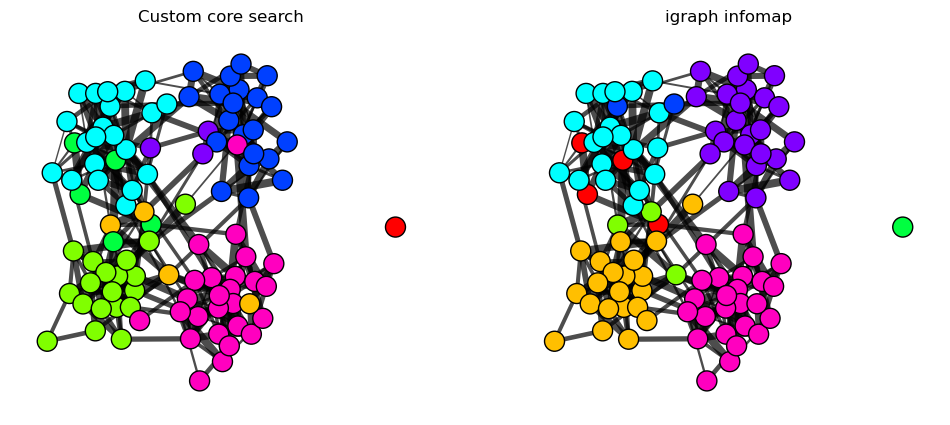

In [19]:
fig, ax = plt.subplots(ncols=2, figsize = (12, 5))
ig.plot(g_test, layout=layout, **inf.visual_community_colors(g_test, communities=comms, skipLayout=True), target=ax[0])
ig.plot(g_test, layout=layout, **inf.visual_community_colors(g_test, communities=comms_ig.membership, skipLayout=True), target=ax[1])
ax[0].set_title("Custom core search")
ax[1].set_title("igraph infomap")
plt.show()

Then directed:

In [20]:
comms = core_search_algorithm(g_test_directed, verbose=True)
L_test = inf.compute_description_length(g_test_directed, comms)
print("Our best infomap description length: ", L_test)
# testing igraphs infomap implementation
comms_ig = g_test_directed.community_infomap(edge_weights="weight")
print("Igraph's best infomap description length: ", comms_ig.codelength)
print("Description length of igraph's best community assignment computed with our function: ", inf.compute_description_length(g_test_directed, comms_ig.membership))


--- Level 0 ------------------------------
    Current Graph: 100 nodes, 702 edges
Initialising node movement optimization with each node in its own community.
Starting from description length: 8.421062110291702
Current best description length: 6.919842269725915
Number of nodes moved this iteration: 79
Continuing optimization.
Current best description length: 6.5822784309813
Number of nodes moved this iteration: 25
Continuing optimization.
Current best description length: 6.37736861957522
Number of nodes moved this iteration: 13
Continuing optimization.
Current best description length: 6.158922003215748
Number of nodes moved this iteration: 13
Continuing optimization.
Current best description length: 6.084815250200062
Number of nodes moved this iteration: 2
Continuing optimization.
Current best description length: 6.084815250200062
Number of nodes moved this iteration: 0
Optimization finished!
Final number of communities: 13
Final description length: 6.084815250200062
    Phase 1 foun

In [21]:
compare_partitions(comms, comms_ig.membership)

Comparing partitions:
Partition 1: 5 communities
Partition 2: 4 communities
Normalized Mututal Information: 0.9551
Adjusted Rand Index: 0.9596


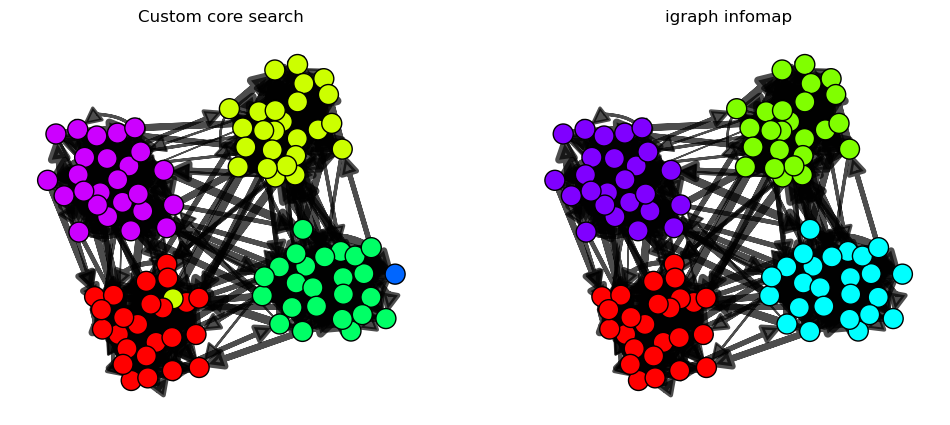

In [22]:
fig, ax = plt.subplots(ncols=2, figsize = (12, 5))
ig.plot(g_test_directed, layout=layout_directed, **inf.visual_community_colors(g_test_directed, communities=comms, skipLayout=True), target=ax[0])
ig.plot(g_test_directed, layout=layout_directed, **inf.visual_community_colors(g_test_directed, communities=comms_ig.membership, skipLayout=True), target=ax[1])
ax[0].set_title("Custom core search")
ax[1].set_title("igraph infomap")
plt.show()

### Refinements: Recursive submodule movements

The recursive submodule refinements are explored in a different notebook (`SubmoduleRefinement.ipynb`)